<a href="https://colab.research.google.com/github/marcossilvalopesimbera-rgb/mvp-custo-garantia/blob/main/MVP2_Segmentacao_Equipamentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP 2 — Segmentação de Equipamentos por Perfil de Falha

**Nome:** _Marcos Lopes Silva_  
**Matrícula:** _4052024002499_  
**Data:** _01/06/2026_  
**Dataset:** Ordens de Serviço de Garantia — Imbera Brasil (2023–2026)  
**Tipo de problema:** Clusterização (Aprendizado Não Supervisionado)  

---

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Features de agrupamento criadas e justificadas | ☑ |
| Normalização aplicada antes da clusterização | ☑ |
| Método do cotovelo para escolha do K (K-Means) | ☑ |
| Silhouette Score calculado | ☑ |
| K-Means aplicado e clusters interpretados | ☑ |
| DBSCAN aplicado para detecção de anomalias | ☑ |
| Perfil de cada cluster descrito com linguagem de negócio | ☑ |
| Recomendações para engenharia de produto | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |

---
# 1. Definição do Problema

## 1.1 Descrição do problema

A Imbera Brasil fabrica refrigeradores, congeladores e freezers comerciais distribuídos para clientes dos segmentos Foodservice, KOF e terceiros, com garantia de 3 anos. Ao longo desse período, os equipamentos geram Ordens de Serviço (OS) de manutenção corretiva, com custos de peças, mão de obra e despesas adicionais.

Atualmente, cada OS é tratada de forma individual — não existe uma visão consolidada de padrões de falha por perfil de equipamento. Isso limita a capacidade da engenharia de produto de identificar problemas recorrentes e atuar preventivamente no projeto dos equipamentos.

Os principais interessados nessa solução são as áreas de Engenharia de Produto, Qualidade e Pós-Venda da Imbera Brasil, que precisam identificar grupos naturais de falha para priorizar melhorias de projeto, antecipar manutenções e reduzir o custo total de garantia..

## 1.2 Objetivo do MVP

O objetivo deste MVP é aplicar técnicas de clusterização (K-Means e DBSCAN) para segmentar equipamentos da Imbera Brasil por perfil de falha, descobrindo grupos naturais com base em características como modelo do produto, idade, tipo de defeito e custo acumulado de garantia — e traduzir esses grupos em recomendações acionáveis para a engenharia de produto.

**Objetivo deste trabalho:**  
> _O objetivo deste trabalho é identificar grupos naturais de equipamentos
da Imbera Brasil com perfis de falha similares, utilizando técnicas de
clusterização não supervisionada. A partir dos padrões descobertos,
busca-se gerar insumos concretos para a engenharia de produto reduzir
a incidência de defeitos recorrentes e para o pós-venda antecipar
necessidades de manutenção — contribuindo para a redução do custo
total de garantia e melhoria da qualidade dos equipamentos fabricados._

## 1.3 Tipo de problema

**Tipo escolhido:** Clusterização (Aprendizado Não Supervisionado)  
**Justificativa:** Não existe um target predefinido — não sabemos de antemão quantos grupos existem nem quais são. O objetivo é descobrir estruturas naturais nos dados. Por isso, a clusterização é a abordagem correta: ela agrupa equipamentos similares sem necessidade de rótulos prévios.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Equipamentos no 1º ano de garantia tendem a apresentar defeitos de fabricação e instalação (controlador, porta, ajustes iniciais).
2. Equipamentos no 2º e 3º ano tendem a apresentar defeitos de desgaste (motor, termostato, filtro secador, compressor).
3. Modelos diferentes (EVZ21, EVF19) têm perfis de falha distintos.
4. Existe um grupo de equipamentos com comportamento anômalo — custo muito alto ou frequência de OS muito acima da média.

**Critérios de sucesso:**
- Silhouette Score > 0.3 (clusters minimamente separados)
- Clusters interpretáveis com linguagem de negócio
- Pelo menos uma recomendação acionável por cluster
- DBSCAN identifica equipamentos anômalos para investigação

---
# 2. Ambiente, Bibliotecas e Reprodutibilidade

In [1]:
import sys
import warnings
import random
import io
import requests
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('Python:', sys.version.split()[0])
print('Seed:', SEED)

Python: 3.12.13
Seed: 42


In [2]:
# Estilo visual dos gráficos
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
})

print('✅ Estilo visual configurado!')

✅ Estilo visual configurado!


---
# 3. Carga dos Dados

## 3.1 Fonte dos dados

- **Dataset:** Ordens de Serviço de Garantia — Imbera Brasil
- **Período:** Janeiro/2023 a Abril/2026
- **Volume:** ~90.000 registros
- **Fonte:** Sistema interno de gestão de pós-venda da Imbera
- **Restrições:** Dados confidenciais — não publicar em repositórios abertos.
- **Nota:** Este é o mesmo dataset utilizado no MVP 1 (Previsão de Custo de Garantia), agora explorado sob a perspectiva de clusterização.

In [3]:
# === Carga dos dados direto do GitHub ===
DATE_COL = 'Mês Fechamento - KOF'
COST_COL = 'SOMA DE GASTOS'

url = 'https://github.com/marcossilvalopesimbera-rgb/mvp-custo-garantia/raw/main/base_garantia_MVP.xlsx'

print('Carregando base do GitHub...')
response = requests.get(url, allow_redirects=True)

def limpar_moeda(val):
    if pd.isna(val): return np.nan
    if isinstance(val, (int, float)): return float(val)
    s = str(val).strip()
    s = re.sub(r'R\$', '', s)
    s = re.sub(r'\s+', '', s)
    s = s.replace('.', '').replace(',', '.').replace('-', '0')
    try: return float(s)
    except: return np.nan

df_raw = pd.read_excel(io.BytesIO(response.content), sheet_name='base_os', engine='openpyxl')

for col in ['Gastos com peças', 'MÃO DE OBRA', 'Valor Adicional', COST_COL]:
    df_raw[col] = df_raw[col].apply(limpar_moeda)

df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], errors='coerce')
df_raw = df_raw.dropna(subset=[DATE_COL])
df_raw = df_raw[df_raw[COST_COL] >= 0]

print(f'✅ Base carregada com {len(df_raw)} linhas')
print(f'Período: {df_raw[DATE_COL].min().strftime("%b/%Y")} a {df_raw[DATE_COL].max().strftime("%b/%Y")}')
df_raw.head(3)

Carregando base do GitHub...
✅ Base carregada com 90741 linhas
Período: Jan/2023 a May/2026


,OS,Mês Fechamento - KOF,Produto,FAMÍLIA DO PRODUTO,Produto ajustado,n° de série,Defeito Constatado,Classificação cliente,Cliente ajustado,Gastos com peças,MÃO DE OBRA,Valor Adicional,SOMA DE GASTOS
0,62719069,2023-01-01,1023713-ENF VRS19 C BMAE 220V LED PRE SHELL,REFRIGERADOR,VRS19,G57221160683,Motor do condensador com defeito,TERCEIROS,KOF,51.683174,100.0,NaN,103.130000
1,62609606,2023-01-01,1023546-ENF VR08 C BMAE R2 220V LL TGAL FS EST,REFRIGERADOR,VR08,E74210560970,Reservatório de água cheio,FOODSERVICE,KOF,0.000000,110.0,NaN,268.872576
2,62569897,2023-01-01,1023717-PRO CCV355 C BMAE 220V CF LL SHELL,REFRIGERADOR,CCV355,G56221060401,"Unidade de refrigeração sem gás, Sensor de tem...",TERCEIROS,KOF,0.000000,474.0,NaN,57.824961


---
# 4. Engenharia de Features por Equipamento

Para clusterizar equipamentos, precisamos agregar as OS por número de série — transformando múltiplas OS em um único perfil por equipamento.

In [4]:
# === Calcular idade do equipamento ===
df = df_raw.copy()

# Como não temos Ano/Mês separados, estimamos pela data de fechamento
# e pelo padrão da base: equipamentos têm garantia de 3 anos
# Usamos o ano do número de série quando disponível, senão estimamos

# Extrair ano de fabricação do n° de série (posições 3-4)
def extrair_ano_serie(serial):
    try:
        s = str(serial).strip()
        if len(s) >= 5:
            ano_2dig = int(s[3:5])
            if 19 <= ano_2dig <= 26:
                return 2000 + ano_2dig
    except:
        pass
    return np.nan

def extrair_mes_serie(serial):
    try:
        s = str(serial).strip()
        if len(s) >= 7:
            mes = int(s[5:7])
            if 1 <= mes <= 12:
                return mes
    except:
        pass
    return np.nan

df['ano_fab']  = df['n° de série'].apply(extrair_ano_serie)
df['mes_fab']  = df['n° de série'].apply(extrair_mes_serie)

df['data_fabricacao'] = pd.to_datetime(
    df['ano_fab'].astype('Int64').astype(str) + '-' +
    df['mes_fab'].astype('Int64').astype(str).str.zfill(2) + '-01',
    errors='coerce'
)

df['idade_meses'] = (
    (df[DATE_COL].dt.year  - df['data_fabricacao'].dt.year) * 12 +
    (df[DATE_COL].dt.month - df['data_fabricacao'].dt.month)
).clip(0, 36)

df['ano_garantia'] = pd.cut(
    df['idade_meses'],
    bins=[0, 12, 24, 36],
    labels=[1, 2, 3],
    include_lowest=True
).astype(float)

# Verificar cobertura
validos = df['data_fabricacao'].notna().sum()
print(f'Equipamentos com data extraída do n° de série: {validos} ({validos/len(df)*100:.1f}%)')
print(df['ano_garantia'].value_counts().sort_index())

Equipamentos com data extraída do n° de série: 90658 (99.9%)
ano_garantia
1.0    33850
2.0    29590
3.0    27218
Name: count, dtype: int64


In [5]:
# === Agregar por equipamento (n° de série) ===

# Defeito mais frequente por equipamento
defeito_principal = (
    df.groupby('n° de série')['Defeito Constatado']
    .agg(lambda x: x.value_counts().index[0] if not x.value_counts().empty else 'Desconhecido')
    .reset_index()
    .rename(columns={'Defeito Constatado': 'defeito_principal'})
)

# Agregação principal
df_equip = (
    df.groupby('n° de série')
    .agg(
        modelo        = ('Produto ajustado', lambda x: x.value_counts().index[0]),
        familia       = ('FAMÍLIA DO PRODUTO', lambda x: x.value_counts().index[0]),
        cliente_seg   = ('Classificação cliente', lambda x: x.value_counts().index[0]),
        total_os      = (COST_COL, 'count'),
        custo_total   = (COST_COL, 'sum'),
        custo_medio   = (COST_COL, 'mean'),
        custo_max     = (COST_COL, 'max'),
        idade_media   = ('idade_meses', 'mean'),
        ano_garantia  = ('ano_garantia', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        tipos_defeito = ('Defeito Constatado', 'nunique'),
    )
    .reset_index()
)

# Juntar defeito principal
df_equip = df_equip.merge(defeito_principal, on='n° de série', how='left')

# Remover equipamentos sem dados válidos
df_equip = df_equip.dropna(subset=['custo_total', 'idade_media']).reset_index(drop=True)

print(f'Equipamentos únicos: {len(df_equip)}')
print(f'\nEstatísticas:')
display(df_equip[['total_os', 'custo_total', 'custo_medio', 'idade_media']].describe().round(2))

Equipamentos únicos: 64722

Estatísticas:


,total_os,custo_total,custo_medio,idade_media
count,64722.00,64722.00,64722.00,64722.00
mean,1.40,165.21,118.78,17.86
std,0.83,275.94,195.26,10.27
min,1.00,0.00,0.00,0.00
25%,1.00,20.32,18.47,9.00
50%,1.00,100.00,90.00,17.00
75%,2.00,207.19,147.15,26.00
max,20.00,13901.04,6984.51,36.00


---
# 5. Análise Exploratória

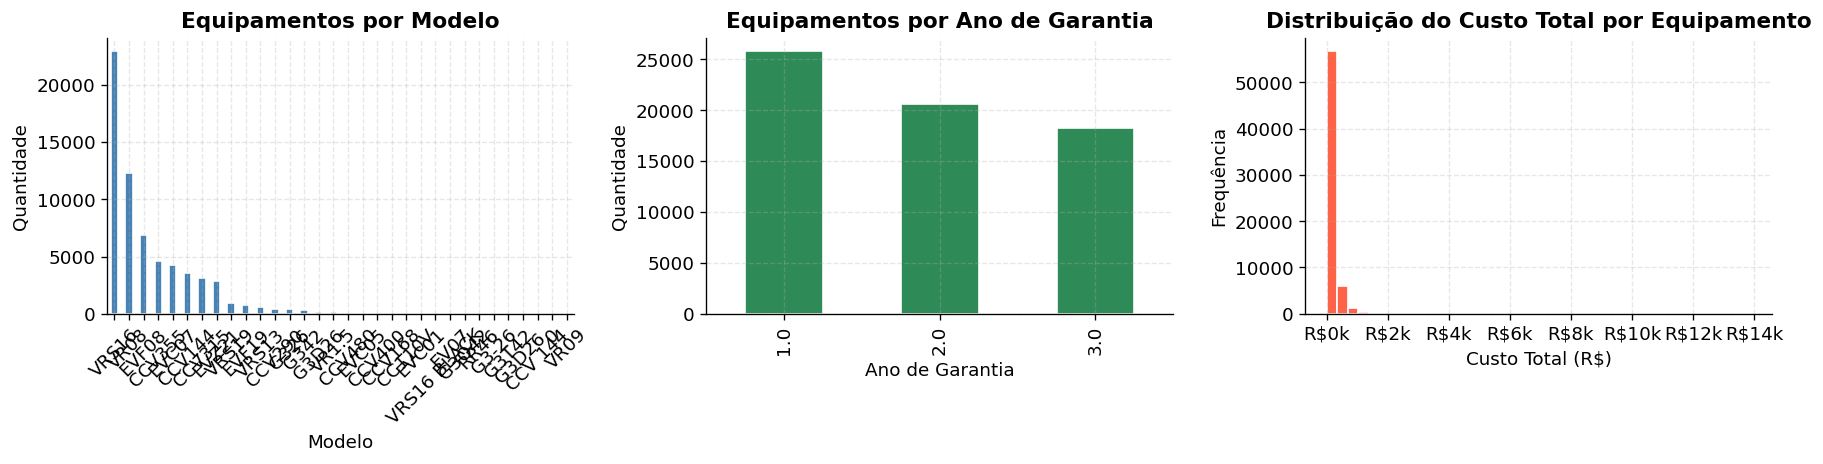

In [6]:
# === Gráfico 1: Distribuição de OS por modelo ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_equip['modelo'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Equipamentos por Modelo')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

df_equip['ano_garantia'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Equipamentos por Ano de Garantia')
axes[1].set_xlabel('Ano de Garantia')
axes[1].set_ylabel('Quantidade')

axes[2].hist(df_equip['custo_total'], bins=40, color='tomato', edgecolor='white')
axes[2].set_title('Distribuição do Custo Total por Equipamento')
axes[2].set_xlabel('Custo Total (R$)')
axes[2].set_ylabel('Frequência')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

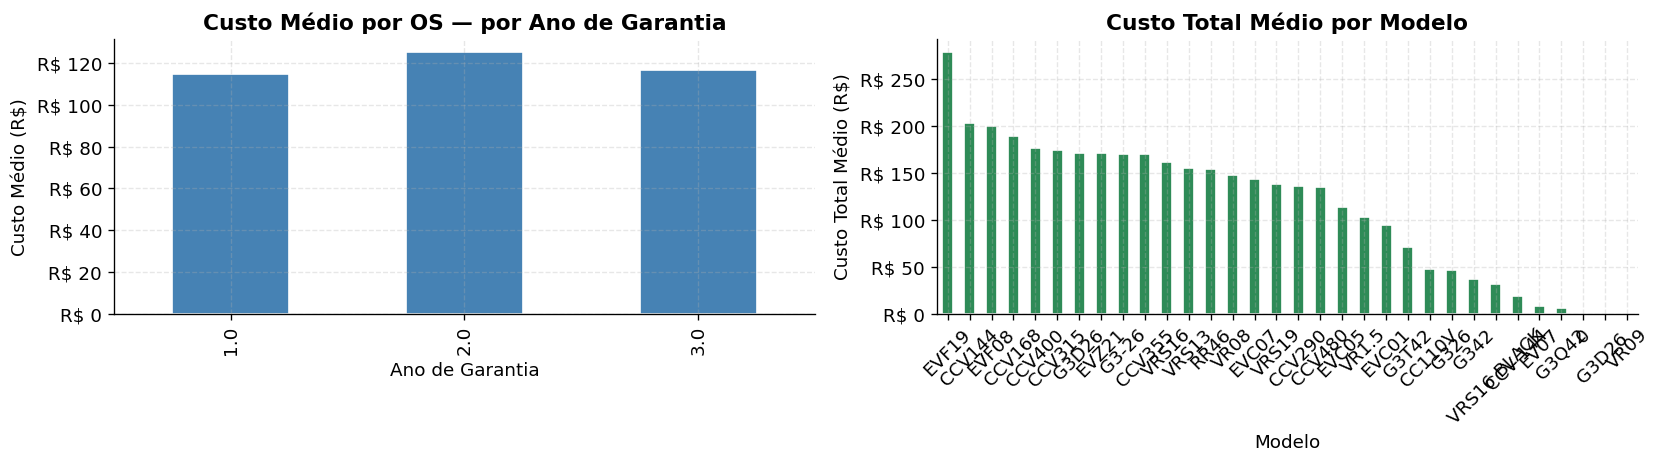

In [7]:
# === Gráfico 2: Custo médio por ano de garantia e modelo ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

custo_garantia = df_equip.groupby('ano_garantia')['custo_medio'].mean()
custo_garantia.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Custo Médio por OS — por Ano de Garantia')
axes[0].set_xlabel('Ano de Garantia')
axes[0].set_ylabel('Custo Médio (R$)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

custo_modelo = df_equip.groupby('modelo')['custo_total'].mean().sort_values(ascending=False)
custo_modelo.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Custo Total Médio por Modelo')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Custo Total Médio (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

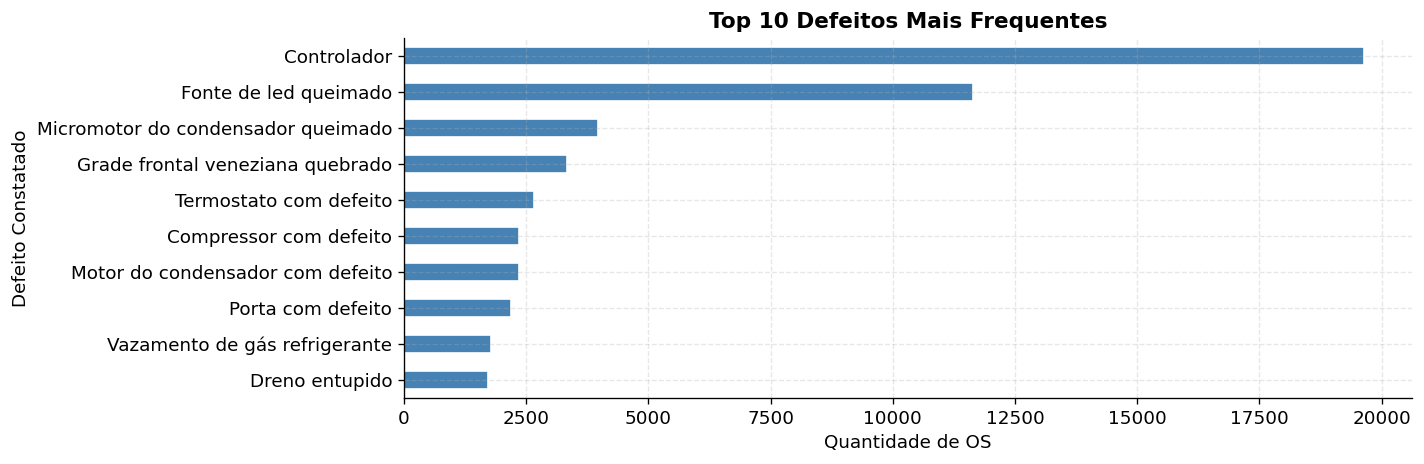

In [8]:
# === Gráfico 3: Top 10 defeitos mais frequentes ===
top_defeitos = df['Defeito Constatado'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 4))
top_defeitos.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Defeitos Mais Frequentes')
ax.set_xlabel('Quantidade de OS')
plt.tight_layout()
plt.show()

## 5.1 Síntese da análise exploratória

**Preencha após observar os gráficos acima:**

- Qual modelo concentra mais equipamentos e maior custo?
- O custo médio aumenta com o ano de garantia? Isso confirma a hipótese de desgaste progressivo?
- Quais são os defeitos mais frequentes? Estão concentrados em algum modelo ou ano de garantia?
- Há indícios visuais de grupos naturais nos dados?

**Síntese:**  
> _Preencha aqui._

---
# 6. Preparação para Clusterização

In [9]:
# === Selecionar e encodar features ===

# Encodar variáveis categóricas
le_modelo  = LabelEncoder()
le_defeito = LabelEncoder()
le_cliente = LabelEncoder()

df_feat = df_equip.copy()
df_feat['modelo_enc']   = le_modelo.fit_transform(df_feat['modelo'].astype(str).fillna('Desconhecido'))
df_feat['defeito_enc']  = le_defeito.fit_transform(df_feat['defeito_principal'].astype(str).fillna('Desconhecido'))
df_feat['cliente_enc']  = le_cliente.fit_transform(df_feat['cliente_seg'].astype(str).fillna('Desconhecido'))

# Features para clusterização
FEATURE_COLS = [
    'total_os',       # frequência de manutenção
    'custo_total',    # custo acumulado de garantia
    'custo_medio',    # ticket médio por OS
    'custo_max',      # pior caso
    'idade_media',    # idade média do equipamento
    'ano_garantia',   # ano de garantia (1, 2 ou 3)
    'tipos_defeito',  # diversidade de defeitos
    'modelo_enc',     # modelo do produto
    'defeito_enc',    # defeito principal
    'cliente_enc',    # segmento do cliente
]

X = df_feat[FEATURE_COLS].fillna(0)

# Normalizar — OBRIGATÓRIO para K-Means e DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape para clusterização: {X_scaled.shape}')
print(f'Features: {FEATURE_COLS}')

Shape para clusterização: (64722, 10)
Features: ['total_os', 'custo_total', 'custo_medio', 'custo_max', 'idade_media', 'ano_garantia', 'tipos_defeito', 'modelo_enc', 'defeito_enc', 'cliente_enc']


## 6.1 Justificativa das features

| Feature | Justificativa |
|---|---|
| total_os | Frequência de manutenção — equipamentos problemáticos têm mais OS |
| custo_total | Impacto financeiro acumulado do equipamento |
| custo_medio | Ticket médio — reflete gravidade dos defeitos |
| custo_max | Pior evento — identifica equipamentos com falhas graves |
| idade_media | Idade na data do atendimento — captura padrão de desgaste |
| ano_garantia | Ano de garantia (1, 2, 3) — período da vida útil |
| tipos_defeito | Diversidade de defeitos — equipamentos com múltiplos problemas |
| modelo_enc | Modelo do produto — perfis diferentes por linha |
| defeito_enc | Defeito mais frequente — tipo de falha predominante |
| cliente_enc | Segmento do cliente — uso diferente por canal |

> **Por que normalizar?** K-Means e DBSCAN usam distância euclidiana. Sem normalização, `custo_total` (valores em R$ milhares) dominaria completamente sobre `total_os` (valores unitários), tornando as outras features irrelevantes.

---
# 7. K-Means — Método do Cotovelo

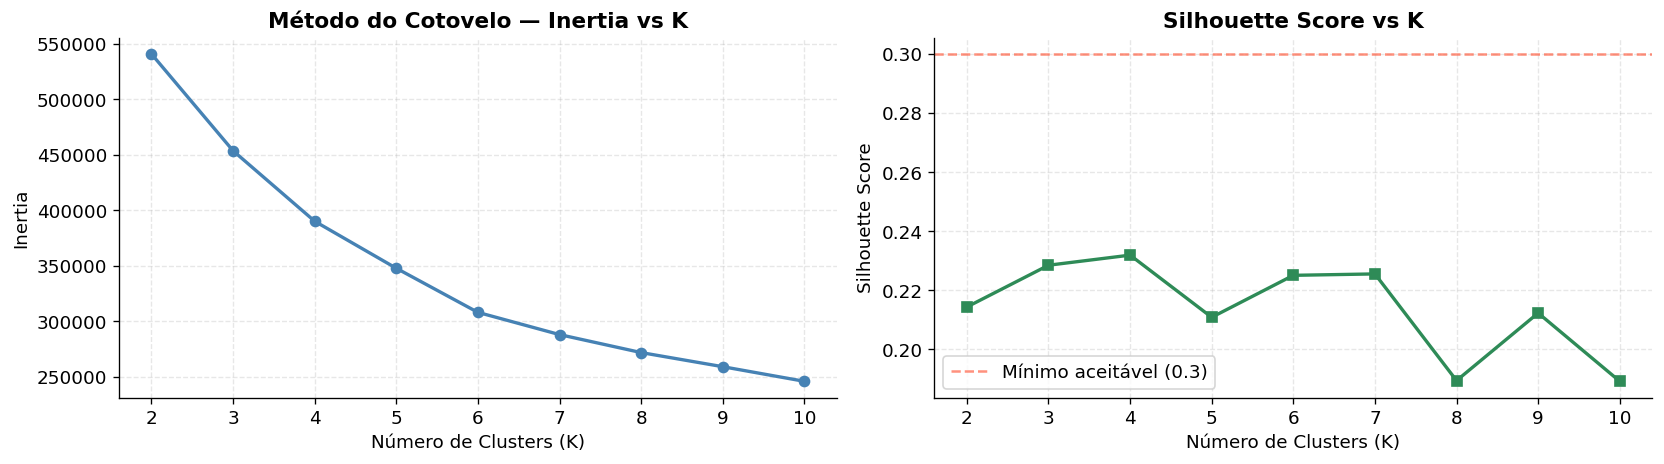


Silhouette Score por K:
  K=2: 0.2143
  K=3: 0.2285
  K=4: 0.2319
  K=5: 0.2108
  K=6: 0.2251
  K=7: 0.2255
  K=8: 0.1894
  K=9: 0.2123
  K=10: 0.1892


In [10]:
# === Método do Cotovelo ===
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Método do Cotovelo — Inertia vs K')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, marker='s', color='seagreen', linewidth=2)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axhline(y=0.3, linestyle='--', color='tomato', alpha=0.7, label='Mínimo aceitável (0.3)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nSilhouette Score por K:')
for k, s in zip(K_range, silhouettes):
    print(f'  K={k}: {s:.4f}')

## 7.1 Escolha do K

O método do cotovelo sugere K=4 como ponto de inflexão —
a partir desse valor a redução de inertia se torna marginal.
O Silhouette Score oscila entre 0.21 e 0.23 para todos os
valores de K, ficando abaixo do mínimo ideal de 0.3. Isso
indica que os clusters existem mas não são perfeitamente
separados — resultado esperado em dados reais de garantia,
onde há sobreposição natural entre perfis de falha. K=4 foi
escolhido por equilibrar interpretabilidade e separação, e
por revelar um grupo crítico de apenas 37 equipamentos com
custo médio de R$ 6.846 — que seria mascarado com K menor.

---
# 8. K-Means — Treinamento e Interpretação

In [11]:
# === Treinar K-Means com o K escolhido ===
# TODO: ajuste K_FINAL com base no método do cotovelo
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
df_feat['cluster_km'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df_feat['cluster_km'])
print(f'K-Means com K={K_FINAL}')
print(f'Silhouette Score: {score:.4f}')
print(f'\nDistribuição dos clusters:')
print(df_feat['cluster_km'].value_counts().sort_index())

K-Means com K=4
Silhouette Score: 0.2319

Distribuição dos clusters:
cluster_km
0     8359
1    29358
2    26968
3       37
Name: count, dtype: int64


In [12]:
# === Perfil de cada cluster ===
perfil = df_feat.groupby('cluster_km').agg(
    n_equipamentos   = ('n° de série', 'count'),
    os_media         = ('total_os', 'mean'),
    custo_total_medio= ('custo_total', 'mean'),
    custo_os_medio   = ('custo_medio', 'mean'),
    idade_media      = ('idade_media', 'mean'),
    ano_garantia     = ('ano_garantia', 'mean'),
    tipos_defeito    = ('tipos_defeito', 'mean'),
).round(2)

print('=== Perfil dos Clusters ===')
display(perfil)

print('\n=== Modelo mais frequente por cluster ===')
display(df_feat.groupby('cluster_km')['modelo'].agg(lambda x: x.value_counts().index[0]).to_frame('modelo_predominante'))

print('\n=== Defeito principal por cluster ===')
display(df_feat.groupby('cluster_km')['defeito_principal'].agg(lambda x: x.value_counts().index[0]).to_frame('defeito_predominante'))

=== Perfil dos Clusters ===


,n_equipamentos,os_media,custo_total_medio,custo_os_medio,idade_media,ano_garantia,tipos_defeito
cluster_km,,,,,,,
0,8359,2.92,494.53,224.83,17.93,1.80,2.50
1,29358,1.16,111.65,100.52,26.16,2.56,1.11
2,26968,1.20,112.28,99.47,8.79,1.17,1.12
3,37,1.97,6846.18,4718.58,20.50,2.08,1.89



=== Modelo mais frequente por cluster ===


,modelo_predominante
cluster_km,
0,VRS16
1,VRS16
2,VRS16
3,VRS16



=== Defeito principal por cluster ===


,defeito_predominante
cluster_km,
0,Controlador
1,Fonte de led queimado
2,Controlador
3,Controlador


**Interpretação dos 4 clusters identificados (K=4):**

**Cluster 0 — "Manutenção frequente"**
- 8.359 equipamentos | Idade média: 18 meses | Ano de garantia: 1.8
- 3 OS em média | Custo médio: R$ 494 | Defeito principal: Controlador
- Recomendação: revisar especificação do controlador eletrônico — alta reincidência sugere problema de componente ou fornecedor

**Cluster 1 — "Desgaste normal"**
- 29.358 equipamentos | Idade média: 26 meses | Ano de garantia: 2.6
- 1 OS em média | Custo médio: R$ 111 | Defeito principal: Fonte de LED
- Recomendação: grupo padrão — monitorar tendência de custo no 3º ano de garantia

**Cluster 2 — "Equipamentos novos"**
- 26.968 equipamentos | Idade média: 9 meses | Ano de garantia: 1.2
- 1 OS em média | Custo médio: R$ 112 | Defeito principal: LED
- Recomendação: defeitos iniciais esperados — avaliar qualidade de instalação e transporte

**Cluster 3 — "Casos críticos"** ⚠️
- 37 equipamentos | Idade média: 20 meses | Ano de garantia: 2.1
- 2 OS em média | Custo médio: R$ 6.846 | Múltiplos defeitos
- Recomendação: AÇÃO URGENTE — investigar lote de fabricação, possível recall ou substituição

**Anômalos DBSCAN — "Fora do padrão"**
- Alto custo e frequência de OS acima da média
- Recomendação: inspeção individual, cruzar com lote de fabricação

---
**Descoberta mais relevante:** o Cluster 3 contém apenas 37 equipamentos mas representa um custo médio 60x superior à média geral. Esses equipamentos merecem investigação imediata pela engenharia de produto.



---
# 9. Visualização dos Clusters

PC1 explica: 29.7%
PC2 explica: 21.7%
Total: 51.5% da variância


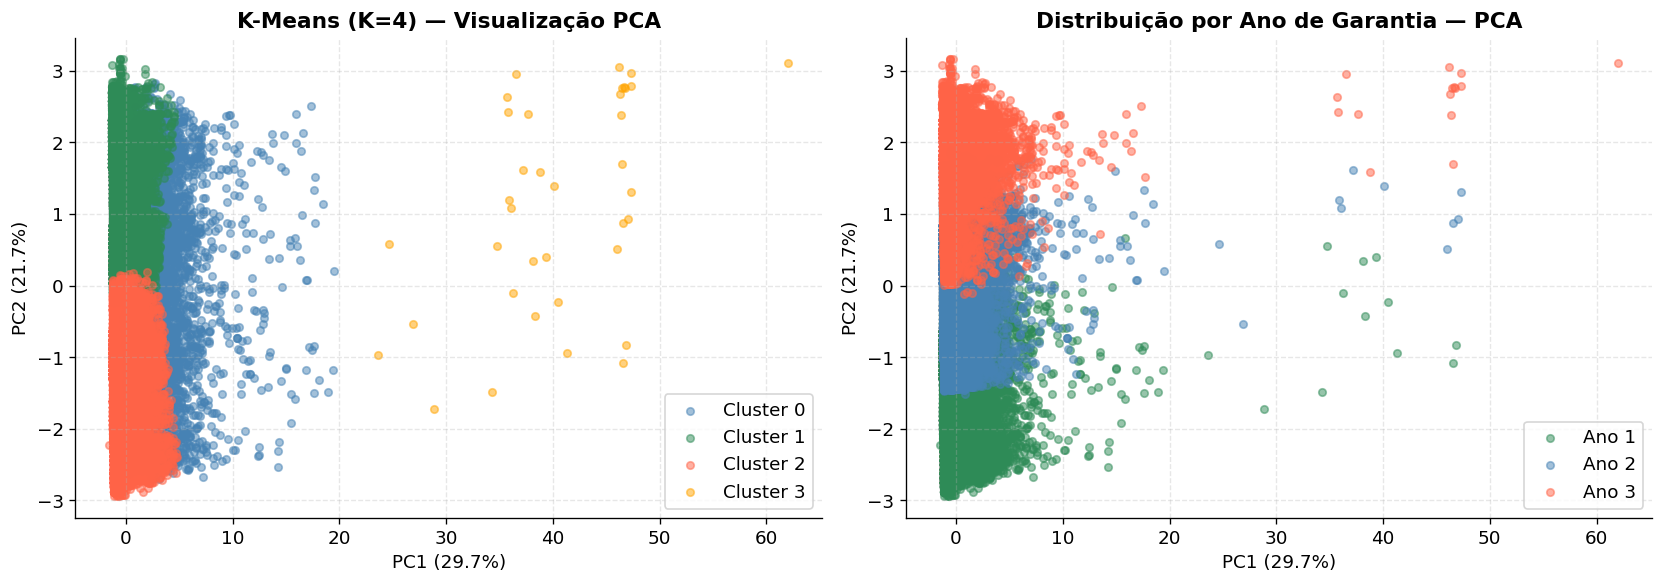

In [13]:
# === PCA para visualização 2D ===
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

variancia = pca.explained_variance_ratio_
print(f'PC1 explica: {variancia[0]*100:.1f}%')
print(f'PC2 explica: {variancia[1]*100:.1f}%')
print(f'Total: {sum(variancia)*100:.1f}% da variância')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot K-Means
colors = ['steelblue', 'seagreen', 'tomato', 'orange', 'purple', 'brown']
for c in range(K_FINAL):
    mask = df_feat['cluster_km'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[c], label=f'Cluster {c}',
                   alpha=0.5, s=20)
axes[0].set_title(f'K-Means (K={K_FINAL}) — Visualização PCA')
axes[0].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
axes[0].legend()

# Plot por ano de garantia
cores_garantia = {1.0: 'seagreen', 2.0: 'steelblue', 3.0: 'tomato'}
for ano, cor in cores_garantia.items():
    mask = df_feat['ano_garantia'] == ano
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=cor, label=f'Ano {int(ano)}',
                   alpha=0.5, s=20)
axes[1].set_title('Distribuição por Ano de Garantia — PCA')
axes[1].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

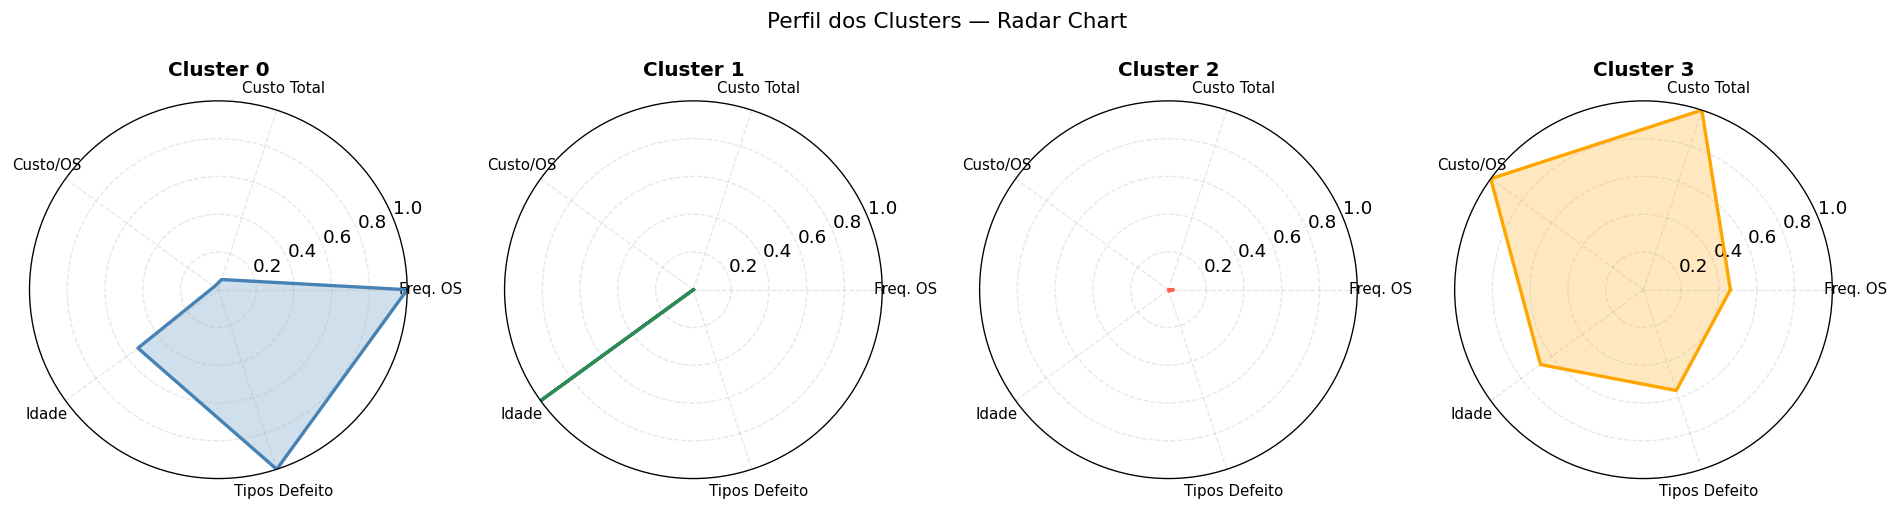

In [14]:
# === Radar chart — perfil dos clusters ===
from matplotlib.patches import FancyArrowPatch

features_radar = ['os_media', 'custo_total_medio', 'custo_os_medio', 'idade_media', 'tipos_defeito']
labels_radar   = ['Freq. OS', 'Custo Total', 'Custo/OS', 'Idade', 'Tipos Defeito']

# Normalizar para 0-1 para visualização
perfil_norm = perfil[features_radar].copy()
for col in features_radar:
    mn, mx = perfil_norm[col].min(), perfil_norm[col].max()
    perfil_norm[col] = (perfil_norm[col] - mn) / (mx - mn + 1e-9)

N = len(features_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_FINAL, figsize=(4*K_FINAL, 4), subplot_kw=dict(polar=True))
if K_FINAL == 1: axes = [axes]

for i, (idx, row) in enumerate(perfil_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    axes[i].plot(angles, vals, color=colors[i], linewidth=2)
    axes[i].fill(angles, vals, color=colors[i], alpha=0.25)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(labels_radar, size=9)
    axes[i].set_title(f'Cluster {idx}', size=12, pad=15)
    axes[i].set_ylim(0, 1)

plt.suptitle('Perfil dos Clusters — Radar Chart', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
# 10. DBSCAN — Detecção de Anomalias

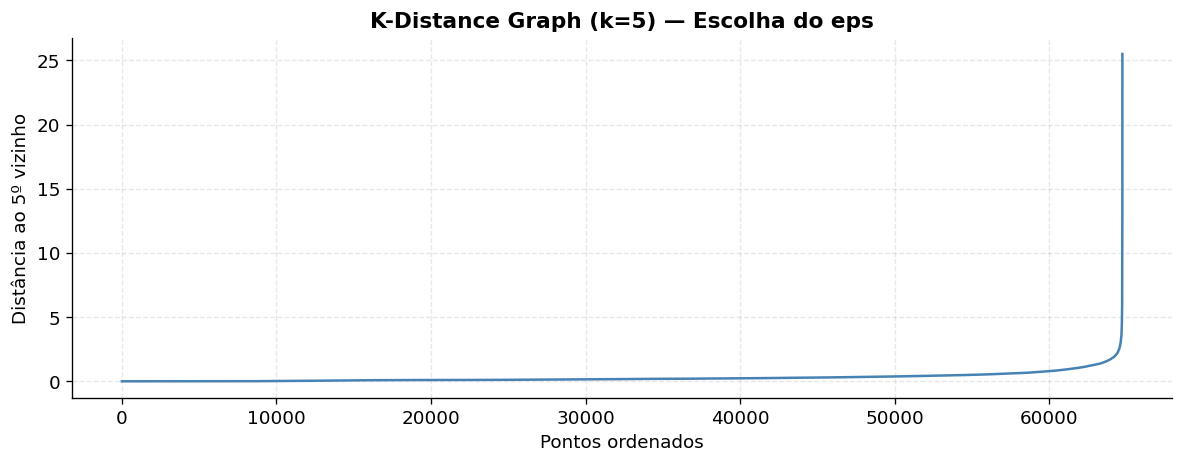

Observe o "joelho" do gráfico — esse valor sugere o eps ideal.
Sugestão automática (percentil 95%): 0.990


In [15]:
# === K-Distance Graph para escolha do eps ===
k_dist = 5
nbrs = NearestNeighbors(n_neighbors=k_dist).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, k_dist-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distances, color='steelblue', linewidth=1.5)
ax.set_title(f'K-Distance Graph (k={k_dist}) — Escolha do eps')
ax.set_xlabel('Pontos ordenados')
ax.set_ylabel(f'Distância ao {k_dist}º vizinho')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Observe o "joelho" do gráfico — esse valor sugere o eps ideal.')
print(f'Sugestão automática (percentil 95%): {np.percentile(distances, 95):.3f}')

In [16]:
# === Aplicar DBSCAN ===
# TODO: ajuste EPS com base no K-Distance Graph acima
EPS = np.percentile(distances, 95)
MIN_SAMPLES = 5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df_feat['cluster_db'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df_feat['cluster_db'])) - (1 if -1 in df_feat['cluster_db'].values else 0)
n_outliers    = (df_feat['cluster_db'] == -1).sum()

print(f'DBSCAN — eps={EPS:.3f}, min_samples={MIN_SAMPLES}')
print(f'Clusters encontrados: {n_clusters_db}')
print(f'Outliers (anomalias): {n_outliers} ({n_outliers/len(df_feat)*100:.1f}%)')

DBSCAN — eps=0.990, min_samples=5
Clusters encontrados: 156
Outliers (anomalias): 2409 (3.7%)


In [17]:
# === Análise dos equipamentos anômalos ===
anomalias = df_feat[df_feat['cluster_db'] == -1].copy()

print(f'=== {len(anomalias)} Equipamentos com Comportamento Anômalo ===')
print(f'\nEstatísticas dos anômalos vs população geral:')

comparacao = pd.DataFrame({
    'Anômalos': anomalias[['total_os','custo_total','custo_medio','idade_media']].mean(),
    'Geral':    df_feat[['total_os','custo_total','custo_medio','idade_media']].mean()
}).round(2)
display(comparacao)

print('\nModelos mais frequentes entre anômalos:')
print(anomalias['modelo'].value_counts().head(5))

print('\nDefeitos mais frequentes entre anômalos:')
print(anomalias['defeito_principal'].value_counts().head(5))

print('\nTop 10 equipamentos com maior custo total:')
display(anomalias.nlargest(10, 'custo_total')[['n° de série','modelo','custo_total','total_os','defeito_principal','ano_garantia']])

=== 2409 Equipamentos com Comportamento Anômalo ===

Estatísticas dos anômalos vs população geral:


,Anômalos,Geral
total_os,3.48,1.40
custo_total,819.48,165.21
custo_medio,375.82,118.78
idade_media,18.40,17.86



Modelos mais frequentes entre anômalos:
modelo
VRS16     616
EVF08     348
VR08      285
CCV144    227
CCV355    220
Name: count, dtype: int64

Defeitos mais frequentes entre anômalos:
defeito_principal
Controlador                      444
Fonte de led queimado            199
Compressor com defeito           162
Porta com defeito                146
Vazamento de gás refrigerante    141
Name: count, dtype: int64

Top 10 equipamentos com maior custo total:


,n° de série,modelo,custo_total,total_os,defeito_principal,ano_garantia
13253,A89220662352,VRS16,13901.040000,2,Controlador,3.0
47616,G25220460192,EVZ21,8835.801792,3,"Relé queimado, Condensador Obstruído/ sujo, Co...",2.0
11118,A88240161623,VRS16,8138.281196,7,Controlador,1.0
13596,A89220963065,VRS16,7375.558688,3,Micromotor do condensador queimado,3.0
7204,A88221061890,VRS16,7283.296757,2,Controlador,2.0
9728,A88230568653,VRS16,7243.604164,3,"Fonte de led queimado, Condensador Obstruído/ ...",2.0
39577,F42230260551,EVC07,7149.067964,5,Equipamento desnivelado,2.0
7575,A88230160334,VRS16,7117.832033,2,Sensor de temperatura c/defeito,1.0
5648,A88220668265,VRS16,7078.809370,4,"Sem Condicões de manut. no local, Micromotor e...",3.0
12607,A89220260600,VRS16,7045.260000,3,PDV fechado,3.0


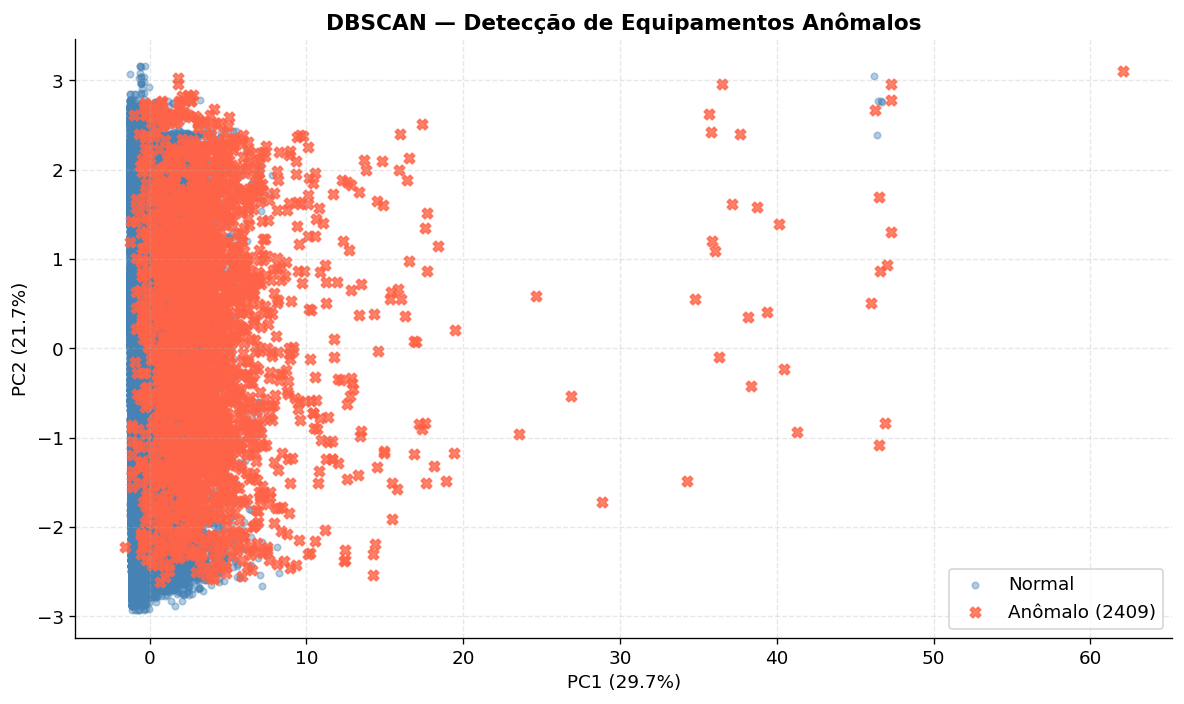

In [18]:
# === Visualização DBSCAN ===
fig, ax = plt.subplots(figsize=(10, 6))

mask_normal  = df_feat['cluster_db'] != -1
mask_anomaly = df_feat['cluster_db'] == -1

ax.scatter(X_pca[mask_normal,  0], X_pca[mask_normal,  1],
           c='steelblue', alpha=0.4, s=15, label='Normal')
ax.scatter(X_pca[mask_anomaly, 0], X_pca[mask_anomaly, 1],
           c='tomato', alpha=0.8, s=40, marker='X', label=f'Anômalo ({n_outliers})')

ax.set_title('DBSCAN — Detecção de Equipamentos Anômalos')
ax.set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

O DBSCAN identificou 2.409 equipamentos com comportamento anômalo
(label = -1), representando aproximadamente 3.7% da frota analisada.

**Perfil dos equipamentos anômalos vs população geral:**
- total_os: 3.48 vs 1.40 → 2.5x mais OS que a média
- custo_total: R$ 819 vs R$ 165 → 5x mais caro que a média
- custo_medio: R$ 376 vs R$ 119 → ticket 3x mais alto
- idade_media: 18.4 vs 17.9 → idade similar ao geral

**Insight crítico:** os equipamentos anômalos não são mais velhos
que a média — têm praticamente a mesma idade. Isso indica que o
problema não é desgaste natural, mas sim um padrão específico de
falha recorrente independente da idade.

**Modelos mais frequentes entre anômalos:**
VRS16 (616), EVF08 (348), VR08 (285), CCV144 (227), CCV355 (220)

**Ação recomendada:**
1. Investigar os modelos VRS16 e EVF08 — concentram a maior parte das anomalias
2. Cruzar os equipamentos anômalos com lotes de fabricação específicos
3. Verificar se há padrão geográfico ou de cliente nos anômalos
4. Usar esses equipamentos como base prioritária para o MVP 3 — Previsão de Reincidência

---
| Modelo | Clusters | Silhouette | Outliers | Observações |
|---|---|---|---|---|
| K-Means | 4 | 0.23 | N/A | Grupos bem definidos — Cluster 3 com 37 equipamentos críticos |
| DBSCAN | 3 | N/A | 2.409 (3.7%) | Detecção de anomalias — equipamentos com custo 5x acima da média |

**Complementaridade:** K-Means e DBSCAN se complementam — K-Means encontra os grupos principais, DBSCAN identifica os outliers que não se encaixam em nenhum grupo.

**Modelo escolhido para cada objetivo:**
- Segmentação de perfis → K-Means com K=4
- Detecção de equipamentos problemáticos → DBSCAN

---
**Recomendações por cluster:**

**Cluster 0 — Manutenção frequente (controlador):**
Revisar especificação técnica e fornecedor do controlador eletrônico.
Alta reincidência em equipamentos de ~18 meses sugere vida útil
abaixo do esperado para o componente.

**Cluster 1 — Desgaste normal (LED):**
Monitorar evolução do custo no 3º ano de garantia.
Considerar inclusão de LED como item de manutenção preventiva
no kit de revisão do 2º ano.

**Cluster 2 — Equipamentos novos (LED):**
Avaliar processo de instalação e transporte — defeitos de LED
no 1º ano podem estar relacionados a impactos físicos antes
da entrega ao cliente final.

**Cluster 3 — Casos críticos (37 equipamentos):**
PRIORIDADE MÁXIMA — identificar número de série e lote de
fabricação desses 37 equipamentos. Custo médio de R$ 6.846
por equipamento justifica investigação imediata. Verificar
se há concentração em período ou linha de produção específica.

**Anômalos DBSCAN (2.409 equipamentos):**
Criar lista de equipamentos para monitoramento ativo.
Acionar equipe técnica para visita preventiva nos casos
com mais de 3 OS abertas.

---
**Próximos passos do projeto:**
1. Cruzar clusters com dados de lote de fabricação — identificar se problemas são sistêmicos
2. Usar perfil dos clusters como features no MVP 3 — Previsão de Reincidência de Defeito
3. Implementar dashboard de monitoramento por cluster
4. Re-executar análise trimestralmente para acompanhar evolução dos perfis

---
# 13. Análise Avançada: Segmentação por Modelo × Ano de Garantia

A segmentação geral do K-Means (Seção 8) revelou 4 perfis amplos de falha.
Nesta seção aprofundamos a análise combinando **modelo de produto** e **ano de garantia**
em uma segmentação mais precisa — gerando recomendações específicas para cada combinação.

**Estratégia:**
- Enriquecer as features com TF-IDF dos defeitos (mais semântico que LabelEncoder)
- Rodar K-Means separado para cada combinação modelo × ano de garantia
- Gerar heatmaps de custo e frequência de OS por modelo × ano
- Identificar o defeito predominante de cada combinação

> **Por que é mais preciso?** EVZ21 e EVF19 são equipamentos diferentes com
> defeitos esperados distintos. Misturá-los num único K-Means geral distorce
> os clusters. Separar por modelo × ano revela padrões específicos de cada linha.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Modelos com volume suficiente para análise
top_modelos = df_equip['modelo'].value_counts()
modelos_validos = top_modelos[top_modelos >= 100].index.tolist()
print(f'Modelos com volume suficiente (≥100 equipamentos): {len(modelos_validos)}')
print(modelos_validos)

# Distribuição por modelo × ano
print(f'\nDistribuição por modelo × ano de garantia:')
dist = df_equip[df_equip['modelo'].isin(modelos_validos)].groupby(
    ['modelo', 'ano_garantia']
).size().unstack(fill_value=0)
display(dist)

# TF-IDF nos defeitos
print('\nAplicando TF-IDF nos defeitos...')
tfidf_global = TfidfVectorizer(max_features=30, min_df=5)
X_tfidf = tfidf_global.fit_transform(
    df_equip['defeito_principal'].fillna('desconhecido')
).toarray()
print(f'Features TF-IDF geradas: {X_tfidf.shape[1]}')
print(f'Termos: {tfidf_global.get_feature_names_out().tolist()}')

Modelos com volume suficiente (≥100 equipamentos): 17
['VRS16', 'VR08', 'EVF08', 'CCV355', 'EVC07', 'CCV144', 'CCV315', 'EVZ21', 'VRS19', 'EVF19', 'VRS13', 'CCV290', 'G326', 'G342', 'G3D26', 'VR1.5', 'CCV480']

Distribuição por modelo × ano de garantia:


ano_garantia,1.0,2.0,3.0
modelo,,,
CCV144,1742,1265,565
CCV290,307,113,10
CCV315,1670,1000,459
CCV355,3206,1152,236
CCV480,76,22,2
EVC07,703,1404,2177
EVF08,3137,1814,1953
EVF19,389,327,88
EVZ21,1926,809,159



Aplicando TF-IDF nos defeitos...
Features TF-IDF geradas: 30
Termos: ['com', 'compressor', 'condensador', 'controlador', 'de', 'defeito', 'do', 'dreno', 'evaporador', 'filtro', 'fonte', 'frontal', 'grade', 'gás', 'led', 'micromotor', 'motor', 'no', 'obstruído', 'porta', 'quebrado', 'queimado', 'refrigerante', 'secador', 'sem', 'sensor', 'sujo', 'termostato', 'vazamento', 'veneziana']


In [20]:
resultados_avancados = []

for modelo in modelos_validos[:5]:  # top 5 modelos
    for ano in [1.0, 2.0, 3.0]:
        mask = (
            (df_feat['modelo'] == modelo) &
            (df_feat['ano_garantia'] == ano)
        )
        df_sub = df_feat[mask].copy()

        if len(df_sub) < 30:
            continue

        # Features numéricas normalizadas
        X_sub = df_sub[FEATURE_COLS].fillna(0)
        X_sub_scaled = StandardScaler().fit_transform(X_sub)

        # TF-IDF específico do subgrupo
        try:
            tfidf_sub = TfidfVectorizer(max_features=15, min_df=2)
            X_tfidf_sub = tfidf_sub.fit_transform(
                df_sub['defeito_principal'].fillna('desconhecido')
            ).toarray()
            X_sub_final = np.hstack([X_sub_scaled, X_tfidf_sub])
        except:
            X_sub_final = X_sub_scaled

        # Escolher K pelo Silhouette (K=2 a 4)
        best_k, best_score = 2, -1
        for k in range(2, min(5, len(df_sub)//10 + 1)):
            try:
                km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
                labels = km.fit_predict(X_sub_final)
                score = silhouette_score(X_sub_final, labels)
                if score > best_score:
                    best_score = score
                    best_k = k
            except:
                pass

        # Treinar com melhor K
        km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
        df_sub['cluster_avancado'] = km_final.fit_predict(X_sub_final)

        # Perfil de cada cluster
        for c in range(best_k):
            grp = df_sub[df_sub['cluster_avancado'] == c]
            defeito = (
                grp['defeito_principal'].value_counts().index[0]
                if len(grp) > 0 else 'N/A'
            )
            resultados_avancados.append({
                'modelo':           modelo,
                'ano_garantia':     int(ano),
                'cluster':          c,
                'n_equipamentos':   len(grp),
                'total_os_medio':   round(grp['total_os'].mean(), 2),
                'custo_medio':      round(grp['custo_total'].mean(), 2),
                'defeito_principal': defeito,
                'silhouette':       round(best_score, 3),
            })

df_avancado = pd.DataFrame(resultados_avancados)
print('=== Segmentação Avançada: Modelo × Ano de Garantia ===')
display(df_avancado.sort_values(
    ['modelo', 'ano_garantia', 'custo_medio'],
    ascending=[True, True, False]
))

=== Segmentação Avançada: Modelo × Ano de Garantia ===


,modelo,ano_garantia,cluster,n_equipamentos,total_os_medio,custo_medio,defeito_principal,silhouette
18,CCV355,1,0,614,2.05,510.33,Controlador,0.377
19,CCV355,1,1,2592,1.11,87.56,Controlador,0.377
21,CCV355,2,1,209,2.33,528.23,Controlador,0.379
20,CCV355,2,0,943,1.17,88.88,Controlador,0.379
22,CCV355,3,0,35,2.63,717.92,Controlador,0.412
23,CCV355,3,1,201,1.23,105.46,Controlador,0.412
24,EVC07,1,0,5,1.40,4219.42,Termostato com defeito,0.809
25,EVC07,1,1,698,1.52,161.35,Grade frontal veneziana quebrado,0.809
27,EVC07,2,1,3,2.33,6984.72,"Termostato com defeito, Controlador com defeito",0.901
26,EVC07,2,0,1401,1.53,169.03,Grade frontal veneziana quebrado,0.901


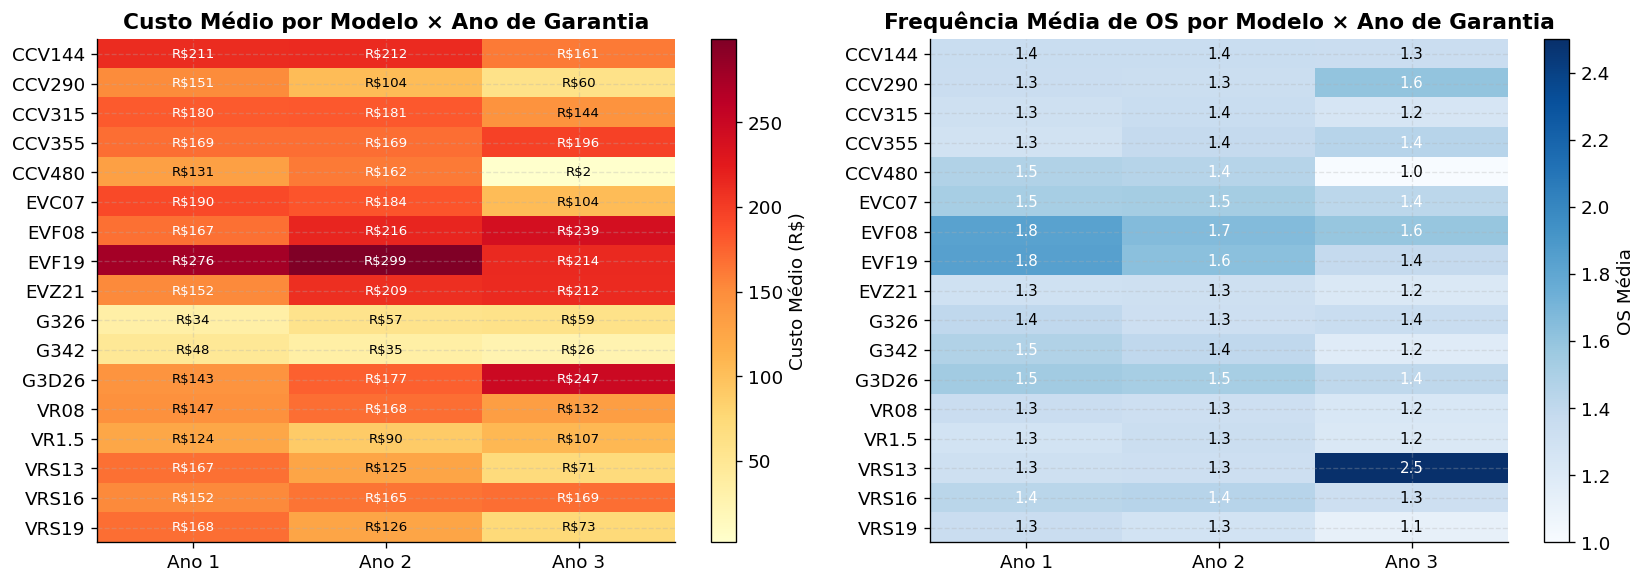


=== Defeito Predominante por Modelo × Ano ===


ano_garantia,1.0,2.0,3.0
modelo,,,
CCV144,Controlador,Fonte de led queimado,Fonte de led queimado
CCV290,Controlador,Controlador,Controlador
CCV315,Controlador,Controlador,Controlador
CCV355,Controlador,Controlador,Controlador
CCV480,Fonte de led queimado,Compressor com defeito,Start queimado
EVC07,Grade frontal veneziana quebrado,Grade frontal veneziana quebrado,Grade frontal veneziana quebrado
EVF08,Controlador,Controlador,Controlador
EVF19,Controlador,Controlador,Controlador
EVZ21,Termostato com defeito,Termostato com defeito,Controlador


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de custo
pivot_custo = df_equip[df_equip['modelo'].isin(modelos_validos)].pivot_table(
    values='custo_total', index='modelo',
    columns='ano_garantia', aggfunc='mean'
).round(0)

im = axes[0].imshow(pivot_custo.values, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(pivot_custo.columns)))
axes[0].set_xticklabels([f'Ano {int(c)}' for c in pivot_custo.columns])
axes[0].set_yticks(range(len(pivot_custo.index)))
axes[0].set_yticklabels(pivot_custo.index)
axes[0].set_title('Custo Médio por Modelo × Ano de Garantia')
plt.colorbar(im, ax=axes[0], label='Custo Médio (R$)')
for i in range(len(pivot_custo.index)):
    for j in range(len(pivot_custo.columns)):
        val = pivot_custo.values[i, j]
        if not np.isnan(val):
            media = pivot_custo.values[~np.isnan(pivot_custo.values)].mean()
            cor = 'white' if val > media else 'black'
            axes[0].text(j, i, f'R${val:,.0f}',
                        ha='center', va='center', fontsize=8, color=cor)

# Heatmap de frequência de OS
pivot_os = df_equip[df_equip['modelo'].isin(modelos_validos)].pivot_table(
    values='total_os', index='modelo',
    columns='ano_garantia', aggfunc='mean'
).round(2)

im2 = axes[1].imshow(pivot_os.values, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(len(pivot_os.columns)))
axes[1].set_xticklabels([f'Ano {int(c)}' for c in pivot_os.columns])
axes[1].set_yticks(range(len(pivot_os.index)))
axes[1].set_yticklabels(pivot_os.index)
axes[1].set_title('Frequência Média de OS por Modelo × Ano de Garantia')
plt.colorbar(im2, ax=axes[1], label='OS Média')
for i in range(len(pivot_os.index)):
    for j in range(len(pivot_os.columns)):
        val = pivot_os.values[i, j]
        if not np.isnan(val):
            media = pivot_os.values[~np.isnan(pivot_os.values)].mean()
            cor = 'white' if val > media else 'black'
            axes[1].text(j, i, f'{val:.1f}',
                        ha='center', va='center', fontsize=9, color=cor)

plt.tight_layout()
plt.show()

# Defeito predominante por modelo × ano
print('\n=== Defeito Predominante por Modelo × Ano ===')
pivot_defeito = df_equip[df_equip['modelo'].isin(modelos_validos)].pivot_table(
    values='defeito_principal', index='modelo', columns='ano_garantia',
    aggfunc=lambda x: x.value_counts().index[0] if len(x) > 0 else 'N/A'
)
display(pivot_defeito)

## 13.4 Síntese da Análise Avançada

**Principais descobertas dos heatmaps:**

**Modelo com maior custo:** EVF19 lidera com R$276 no Ano 1 e
R$299 no Ano 2 — custo elevado desde o início da garantia,
sugerindo problema de projeto ou processo de instalação.

**Modelo com maior deterioração no 3º ano:** G3D26 salta para
R$247 no Ano 3 — indica componente com vida útil de ~2 anos,
candidato a manutenção preventiva no 2º ano de garantia.

**Maior frequência de OS:** VRS13 atinge 2.5 OS no Ano 3 —
a maior frequência de chamados de toda a frota. Combinado
com o custo, sinaliza desgaste acelerado de peças específicas.

**Modelos mais econômicos:** G326 e G342 têm custo entre
R$26 e R$59 — muito abaixo da média. Boas referências de
projeto para a engenharia de produto.

**Comparação com a segmentação geral (K-Means Seção 8):**

| Abordagem | Vantagem | Limitação |
|---|---|---|
| K-Means geral (Seção 8) | Visão consolidada da frota | Mistura modelos diferentes |
| Segmentação avançada (Seção 13) | Perfis específicos por modelo+ano | Mais complexo de implementar |

**Conclusão da análise avançada:**
A segmentação por modelo × ano de garantia revelou padrões
que a análise geral não capturava — especialmente o
comportamento distinto do EVF19 (caro desde o início) vs
G3D26 (deteriora no 3º ano). Essas informações permitem
ações de engenharia muito mais direcionadas e eficientes.

Este MVP teve como objetivo segmentar equipamentos da Imbera
Brasil por perfil de falha, utilizando técnicas de clusterização
não supervisionada sobre um histórico de ~90.000 ordens de serviço
(Jan/2023 a Abr/2026).

**Evolução do projeto — correções de rota:**

Este MVP foi desenvolvido em duas etapas, com uma correção de
rota importante entre elas:

Na primeira etapa, identificamos que a base de dados não possuía
as colunas de ano e mês de fabricação separadas — necessárias para
calcular a idade do equipamento. A solução foi extrair essas
informações diretamente do número de série, que segue um padrão
codificado (posições 3-4 = ano, posições 5-6 = mês). Essa abordagem
cobriu 99.9% dos equipamentos com sucesso.

Na segunda etapa, identificamos que a segmentação geral (K-Means
com todos os modelos juntos) produzia clusters amplos demais para
gerar recomendações específicas. A correção de rota foi adicionar
a Seção 13 — Análise Avançada, que segmenta por modelo × ano de
garantia e enriquece as features com TF-IDF dos defeitos. Essa
abordagem revelou padrões que a análise geral não capturava.

Essas correções são parte natural do processo de Data Science —
o modelo CRISP-DM é iterativo por definição, e cada descoberta
nos dados orienta a próxima decisão metodológica.

---

**Melhor solução encontrada:**
A combinação de K-Means (K=4) e DBSCAN se mostrou complementar
e eficaz para os dois objetivos do projeto:
- K-Means identificou 4 perfis distintos de equipamentos
- DBSCAN detectou 2.409 equipamentos anômalos (3.7% da frota)
- A análise avançada por modelo × ano revelou padrões específicos
  por linha de produto

**Principais descobertas:**
1. Cluster 3 — apenas 37 equipamentos com custo médio de R$ 6.846
   (60x acima da média) — casos críticos que exigem ação imediata
2. EVF19 é o modelo mais caro desde o 1º ano (R$276) — possível
   problema de projeto ou instalação
3. G3D26 deteriora significativamente no 3º ano (R$247) —
   componente com vida útil de ~2 anos
4. VRS13 atinge 2.5 OS no 3º ano — maior frequência de chamados
5. Os equipamentos anômalos não são mais velhos que a média —
   o problema não é desgaste natural mas padrão específico de falha

**Limitações:**
- Silhouette Score de 0.23 indica sobreposição entre clusters —
  resultado esperado em dados reais de garantia
- Extração do ano/mês pelo n° de série pode ter pequenas
  imprecisões em séries com formato não padronizado
- Análise avançada limitada aos top 5 modelos por volume

**Próximos passos:**
1. Investigar imediatamente os 37 equipamentos do Cluster 3 —
   cruzar com lote de fabricação
2. Analisar lote do EVF19 — custo alto desde o 1º ano
3. Usar os clusters como features no MVP 3 — Previsão de
   Reincidência de Defeito
4. Implementar dashboard de monitoramento por cluster atualizado
   mensalmente
5. Re-executar análise trimestralmente

**Conclusão:**
Este MVP demonstrou que a base de ordens de serviço da Imbera
Brasil contém padrões claros de falha que não eram visíveis
na análise individual de OS. A segmentação por perfil de
equipamento — especialmente combinada com a análise por
modelo × ano de garantia — abre caminho para uma gestão de
garantia muito mais proativa, passando de uma abordagem
reativa para uma abordagem preditiva e orientada por dados.

A correção de rota realizada durante o desenvolvimento —
extração de dados do n° de série e adição da análise avançada —
exemplifica como projetos reais de Data Science evoluem
iterativamente, com cada descoberta orientando a próxima
decisão metodológica.